In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
col = ["PassengerId", "Ticket", "Cabin"]
df = df.drop(columns = col)

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB
None


In [4]:
df['FamilySize'] = df["SibSp"] + df['Parch'] + 1

In [5]:
print(df[["SibSp", "Parch", "FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [6]:
df['Title'] = df['Name'].str.extract(r" ([A-Za-z]+)\.", expand = False)
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [7]:
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss",
    "Mme": "Mrs",
    "Dr": "Officer", "Major": "Officer","Rev": "Officer", "Col": "Officer", "Capt": "Officer",
    "Don": "Royalty", "Sir": "Royalty", "Lady": "Royalty", "Countess": "Royalty", "Jonkheer": "Royalty"
}

df["Title"] = df['Title'].replace(title_mapping)
print(df["Title"].value_counts())


Title
Mr         517
Miss       185
Mrs        126
Master      40
Officer     18
Royalty      5
Name: count, dtype: int64


In [8]:
df = df.drop(columns= ["Name"])

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    str    
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    str    
 8   FamilySize  891 non-null    int64  
 9   Title       891 non-null    str    
dtypes: float64(2), int64(5), str(3)
memory usage: 69.7 KB
None


In [10]:
df['Pclass'] = df["Pclass"].astype(str)

In [11]:
df['Sex'] = df['Sex'].map({"male": 0, "female": 1})

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
numeric_features = ["Age", "SibSp", 'Parch', 'Fare', 'FamilySize', 'Sex']
categorical_features =['Pclass', 'Embarked', "Title"]

PIPELINES

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [15]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop = 'first'))
])

CONVERT BOTH TO  COLUMNTRANSFER.

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

NOW TRAINING

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced")
}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test,  pipe.predict(X_test))
    print(f"{name}:  Test: {test_acc} | Train: {train_acc}")

Logistic Regression:  Test: 0.8100558659217877 | Train: 0.8314606741573034
Decision Tree:  Test: 0.7988826815642458 | Train: 0.9817415730337079
Random Forest:  Test: 0.8324022346368715 | Train: 0.9817415730337079


In [18]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv = 5, scoring =  'accuracy')
    print(f"{name}: {scores.mean()} +/- {scores.std()}")

/home/bibek/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/bibek/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Logistic Regression: 0.813148823007978 +/- 0.01694576968311606
Decision Tree: 0.7752979414951245 +/- 0.010512001058805797
Random Forest: 0.7949571555205358 +/- 0.016710664098698626


/home/bibek/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


SO HERE OUR CANDIDATE IS LOGISTIC REGRESSION(warning are because sometimes the rare titles don't appear in both test and train.)

In [19]:
from sklearn.model_selection import GridSearchCV

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state = 42, max_iter = 1000, class_weight = 'balanced'))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", 'l2'],
    "model__solver": ['liblinear'] # supports both l1 and l2
}
#model__ . prefix is  used as a routing syntax during pipeline use.

grid = GridSearchCV(lr_pipe, param_grid, cv = 5, n_jobs = -1, scoring = 'accuracy')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

best_lr = grid.best_estimator_
print("Test accuracy:", best_lr.score(X_test, y_test))

/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio o

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
0.8159657244164287
Test accuracy: 0.7932960893854749


/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/bibek/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/bibek/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and 

In [20]:
from sklearn.metrics import classification_report

y_pred = best_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       105
           1       0.73      0.80      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



In [21]:

# get feature names after preprocessing (numeric stays same, categorical gets expanded by OHE)
feature_names = (
    numeric_features +
    list(best_lr.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_features))
)

coefs = best_lr.named_steps['model'].coef_[0]

coef_df = pd.Series(coefs, index=feature_names).sort_values()
print(coef_df)

Title_Mr        -2.040300
Pclass_3        -1.317000
Title_Officer   -1.315308
Pclass_2        -0.425730
Embarked_S      -0.368541
Age             -0.313161
SibSp           -0.293074
FamilySize      -0.279577
Title_Miss      -0.208801
Parch           -0.158679
Embarked_Q      -0.111155
Title_Royalty    0.184222
Fare             0.339493
Sex              0.344862
Title_Mrs        0.899838
dtype: float64


In [22]:
print(type(best_lr))
print(best_lr.named_steps)

<class 'sklearn.pipeline.Pipeline'>
{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
                                  'Sex']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Pclass', 'Embarked', 'Title'])]), 'model': LogisticRegression(C=1, class_weight='balanced', max_

In [23]:
import joblib
joblib.dump(best_lr, "Titanic_v2.pkl")

['Titanic_v2.pkl']

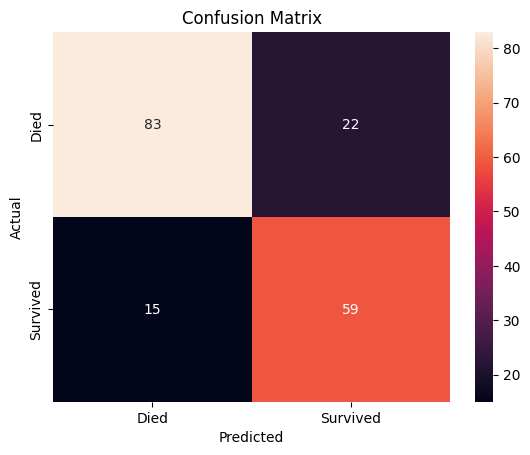

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=["Died","Survived"], yticklabels=["Died","Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
import xgboost as xgb
print(xgb.__version__)

3.3.0


NOW WE ARE BOOSTING THE MODEL

In [27]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss'))
])

scores = cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost: {scores.mean():.4f} +/- {scores.std():.4f}")

1.6567164179104477
XGBoost: 0.7809 +/- 0.0102


/home/bibek/.local/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
